# 12 · Incrementality & real-data validation — ghost ads, holdouts, and Criteo

**NB 12** (the finale). The hardest question in marketing/rewards: does the ad/reward **cause**
conversions, or just **take credit** for ones that would have happened anyway? Naive **attribution**
credits every conversion among the exposed to the campaign — and is wildly biased (Lewis–Rao 2015). The
fix is a **holdout** (ghost ads / PSA): an eligible control with the ad **withheld**. We:
1. author a ghost-ads DGP and show naive attribution overstates **several-fold**, while the holdout
   recovers the truth — and **CACE** (ITT ÷ exposure) recovers the effect on the *exposed* (IV/LATE);
2. run the **same estimator on the real Criteo Uplift RCT** (13.9M rows) — no ground truth, so we check
   it **behaves sensibly at scale**. The answer to "real business context."

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY
sig = lambda z: 1 / (1 + np.exp(-z))

## 1. A ghost-ads world (authored truth)

Users have an **organic** conversion propensity $p_0(x)$ (they'd convert anyway). We randomize
**eligibility** (treatment vs **holdout**); eligible users are **exposed** with a *targeted* probability
(high-$x$ users see the ad more). Exposure adds the true incremental effect $\tau$:
$$Y\sim\text{Bernoulli}\big(p_0(x)+\tau\cdot\text{exposed}\big),\quad p_0(x)=\sigma(-3.2+0.8x).$$
The true effect of **exposure on conversion is $\tau=0.015$**; the holdout is the clean counterfactual.

In [2]:
def simulate_ghost_ads(n=400_000, tau=0.015, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(n)
    p0 = sig(-3.2 + 0.8 * x)                              # organic conversion ~4%, higher for high-x
    elig = rng.random(n) < 0.5                            # RCT: eligible (treatment) vs holdout
    shown = elig & (rng.random(n) < sig(-0.4 + 1.2 * x))  # targeted exposure among the eligible
    conv = (rng.random(n) < (p0 + tau * shown)).astype(int)
    return pd.DataFrame({"x": x, "eligible": elig.astype(int), "exposed": shown.astype(int), "conv": conv})

TAU = 0.015
g = simulate_ghost_ads()
naive = g.loc[g.exposed == 1, "conv"].mean()                                  # all exposed conversions
obs = g.loc[g.exposed == 1, "conv"].mean() - g.loc[g.exposed == 0, "conv"].mean()   # exposed − unexposed
print(f"TRUE effect of exposure τ = {TAU}")
print(f"  naive attribution (exposed conversion rate) = {naive:+.4f}   ({naive/TAU:.1f}× the truth)")
print(f"  observational exposed − unexposed           = {obs:+.4f}   (biased by targeting)")

TRUE effect of exposure τ = 0.015
  naive attribution (exposed conversion rate) = +0.0869   (5.8× the truth)
  observational exposed − unexposed           = +0.0413   (biased by targeting)


## 2. The holdout recovers it — ITT and CACE

The **ITT** is the clean RCT contrast (eligible − holdout). Because only a fraction are actually exposed,
ITT $=\tau\cdot\Pr(\text{exposed})$; dividing by the exposure rate gives the **CACE** — the effect on the
*exposed* (the Wald / Bloom estimator, one-sided non-compliance = IV/LATE).

  ghost-ad holdout ITT = +0.0063  (truth τ·exp = 0.0064)
  CACE (ITT ÷ exposure) = +0.0148  (truth τ = 0.015)   ← recovers the per-exposed effect


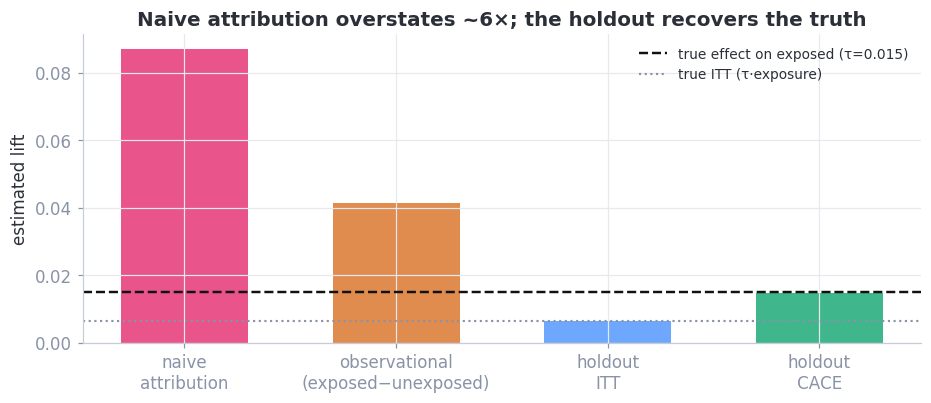

In [3]:
from lyra.incrementality import lift, cace

yt = g.loc[g.eligible == 1, "conv"].to_numpy(); yc = g.loc[g.eligible == 0, "conv"].to_numpy()
itt = lift(yt, yc)
cc = cace(yt, yc, g.loc[g.eligible == 1, "exposed"].to_numpy())
print(f"  ghost-ad holdout ITT = {itt['point']:+.4f}  (truth τ·exp = {TAU*g.loc[g.eligible==1,'exposed'].mean():.4f})")
print(f"  CACE (ITT ÷ exposure) = {cc['point']:+.4f}  (truth τ = {TAU})   ← recovers the per-exposed effect")

fig, ax = plt.subplots(figsize=(8.6, 3.8))
bars = {"naive\nattribution": naive, "observational\n(exposed−unexposed)": obs, "holdout\nITT": itt["point"], "holdout\nCACE": cc["point"]}
cols = [PINK, ORANGE, BLUE, GREEN]
ax.bar(list(bars), list(bars.values()), color=cols, width=.6)
ax.axhline(TAU, color="#111", ls="--", lw=1.6, label=f"true effect on exposed (τ={TAU})")
ax.axhline(TAU * g.loc[g.eligible == 1, "exposed"].mean(), color=GRAY, ls=":", lw=1.4, label="true ITT (τ·exposure)")
ax.set_ylabel("estimated lift"); ax.set_title("Naive attribution overstates ~6×; the holdout recovers the truth"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Naive attribution claims **~6× the real effect** — exactly the Lewis–Rao "unfavorable economics" trap.
The holdout's ITT is unbiased, and CACE recovers the per-exposed effect, validated against $\tau$.

## 3. Real data — the Criteo Uplift RCT (13.9M rows)

Now the **same estimator** on real large-scale data (Diemert et al. 2018). No ground truth → we check it
**behaves sensibly**: a small, highly-significant lift. Regression adjustment (Lin 2013) tightens the
interval — and the *small point shift* it produces flags **mild covariate imbalance**: real data is rarely
a textbook RCT. (We stream a balanced ~560k sample from Hugging Face and cache it — the dataset isn't vendored.)

In [4]:
from validation.criteo import load_sample, FEATURES

cr = load_sample()
t, c = cr[cr.treatment == 1], cr[cr.treatment == 0]
print(f"Criteo sample: {len(cr):,} rows · treatment {cr.treatment.mean():.0%} / control {1-cr.treatment.mean():.0%}")
for o in ["visit", "conversion"]:
    L = lift(t[o].to_numpy(), c[o].to_numpy())
    print(f"  {o:11s} lift = {L['point']:+.4f}  [{L['ci_low']:+.4f}, {L['ci_high']:+.4f}]  z = {L['z']:.1f}")

# regression adjustment — Lin (2013): demeaned treatment×covariate interactions (unbiased for an RCT)
cd = cr.assign(**{f + "_c": cr[f] - cr[f].mean() for f in FEATURES})
lin = smf.ols("visit ~ treatment + " + " + ".join(f + "_c" for f in FEATURES)
              + " + " + " + ".join(f"treatment:{f}_c" for f in FEATURES), cd).fit(cov_type="HC1")
raw = lift(t["visit"].to_numpy(), c["visit"].to_numpy())
print(f"\n  visit lift  raw ITT       : {raw['point']:+.4f} ± {1.96*raw['se']:.4f}")
print(f"  visit lift  Lin-adjusted  : {lin.params['treatment']:+.4f} ± {1.96*lin.bse['treatment']:.4f}  "
      f"(SE −{100*(1-lin.bse['treatment']/raw['se']):.0f}%; small point shift ⇒ mild imbalance)")

Criteo sample: 559,184 rows · treatment 85% / control 15%


  visit       lift = +0.0106  [+0.0091, +0.0120]  z = 14.4
  conversion  lift = +0.0013  [+0.0010, +0.0017]  z = 8.2



  visit lift  raw ITT       : +0.0106 ± 0.0014
  visit lift  Lin-adjusted  : +0.0076 ± 0.0013  (SE −10%; small point shift ⇒ mild imbalance)


## 4. ITT vs CACE on Criteo — the exposed see a big effect

Criteo logs **exposure** (was the ad actually shown). Only a few percent of the treated are exposed, so
the campaign-level **ITT is small (+1pp on visits)** while the **CACE on the exposed is large**. *Caveat:*
unlike our sim, Criteo's exposure isn't randomized within treatment, so CACE leans on the exclusion
assumption — the ITT is the trustworthy number; CACE is suggestive.

In [5]:
cc_cr = cace(t["visit"].to_numpy(), c["visit"].to_numpy(), t["exposure"].to_numpy())
print(f"  visit ITT                 = {cc_cr['itt']:+.4f}   (campaign-level, clean RCT)")
print(f"  exposure rate (treated)   = {cc_cr['exposure_rate']:.1%}")
print(f"  visit CACE (on exposed)   = {cc_cr['point']:+.4f}   (effect on those actually shown — assumption-laden)")

  visit ITT                 = +0.0106   (campaign-level, clean RCT)
  exposure rate (treated)   = 3.6%
  visit CACE (on exposed)   = +0.2934   (effect on those actually shown — assumption-laden)


## 5. Promote → `lyra/incrementality.py` + `validation/criteo.py`

Promoted: `lyra.incrementality` (`lift`, `cace`) and `validation.criteo` (`load_sample`, `validate`).
`tests/test_incrementality.py` asserts naive attribution overstates, the holdout ITT/CACE recover the
authored truth, and the Criteo estimates are stable & significant on real data.

**🏁 The curriculum is complete (NB 01–12 — NB 11 deferred):** spine · DGP-zoo · metrics · cluster-SE ·
interference · switchback · sequential · power/decisions · CATE · uplift/policy · incrementality. The
inference engine is built, every method validated against ground truth, and the headline claim — *the same
estimator works on real Criteo data* — is demonstrated.

In [6]:
from validation.criteo import validate
v = validate(cr)
print("validation.criteo.validate →",
      {k: round(v[k]["point"], 4) for k in ["visit", "conversion"]},
      "| visit CACE", round(v["visit_cace"]["point"], 3))

validation.criteo.validate → {'visit': 0.0106, 'conversion': 0.0013} | visit CACE 0.293
